# Type 42

The support could be $(-\infty, \infty)$. We use Newton's Method to find out the effective support.

However, c++ version sometimes results in type 49 while Python version results in type 42.

It seems that when the moments are small the underling Partial Fraction Decomposition and
polynomial root finding algorithms are not highly reliable!

In [1]:
from pearsondist import Pearson8, Support8
from utils import plot_pdf_cdf, plot_dpdf_pdf
import numpy as np
from pprint import pprint

from joint_mom import comp_joint_moms_mat
from joint_mom_tr import joint_mom_tr

In [2]:
# # preprocessing
# txt = '''          0
#  4.99408e-06
# -1.26248e-09
#  7.67366e-11
# -6.33023e-14
#  2.02988e-15
# -3.41014e-18
#  6.76261e-20'''
# lines = [line.strip() for line in txt.split('\n')]
# string = ','.join(lines)
# print(string)

{'A1': np.float64(-0.049117953379463314),
 'A2': np.float64(0.049117953379463314),
 'B1': np.float64(-0.008210023156082274),
 'B2': np.float64(0.006199377238315147),
 'type': 42,
 'x1': np.complex128(-0.010602197834773255+0.0022525940644989636j),
 'x2': np.complex128(0.009865327575271601+0.001932912960093186j)}
a = -0.0003446194715986678, scale = 9.415197104012687
iteration: 0, x0 =   -0.0143846
iteration: 1, x0 =   -0.0170310
iteration: 2, x0 =   -0.0236306
iteration: 3, x0 =   -0.0515257
iteration: 0, x0 =    0.0136339
iteration: 1, x0 =    0.0163517
iteration: 2, x0 =    0.0234670
iteration: 3, x0 =    0.0558068


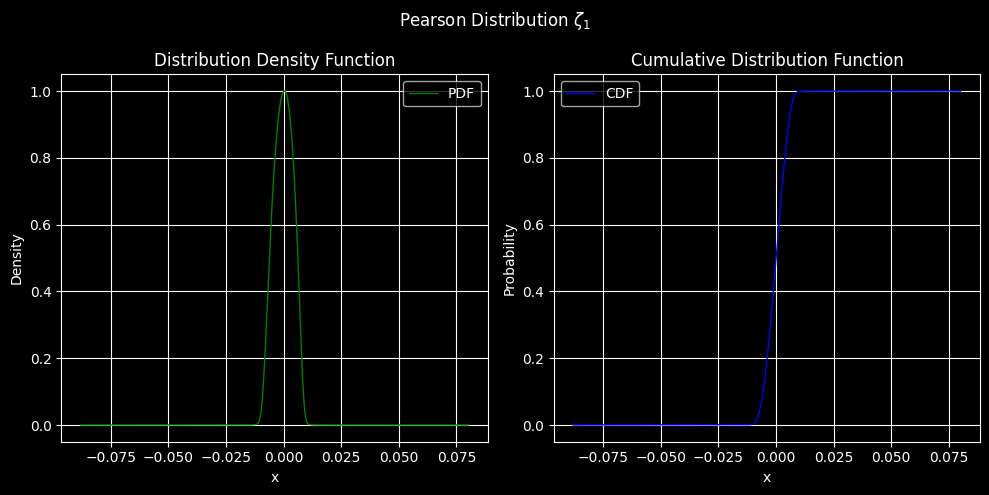

iteration: 0, x0 =   -0.0143846
iteration: 1, x0 =   -0.0170310
iteration: 2, x0 =   -0.0236306
iteration: 3, x0 =   -0.0515257
iteration: 0, x0 =    0.0136339
iteration: 1, x0 =    0.0163517
iteration: 2, x0 =    0.0234670
iteration: 3, x0 =    0.0558068
roots: [-0.00702001  0.00698925]
isMax: True


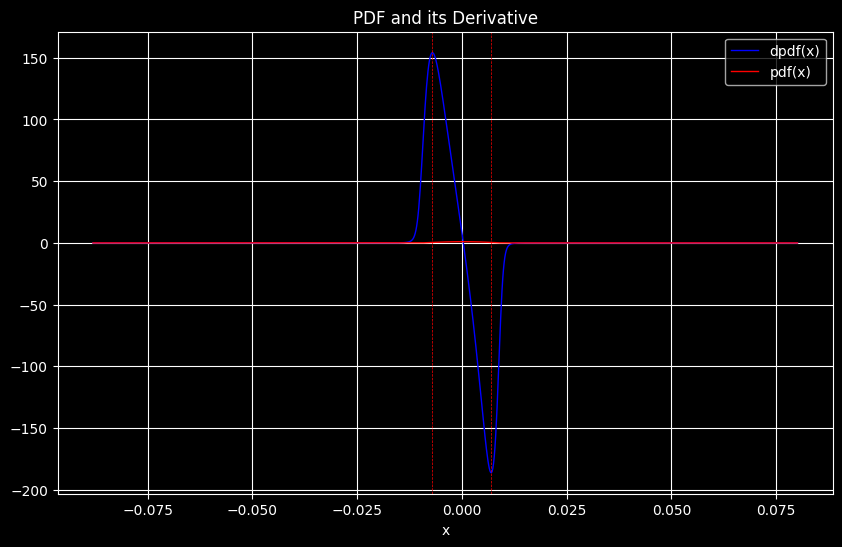

pdf(-0.0880309) = 8.91e-05, pdf(0.0800802) = 7.77e-05


In [3]:
txt1 = "0,2.8948e-06,-9.09822e-10,2.68043e-11,-2.67988e-14,4.47215e-16,-8.87785e-19,9.72059e-21"
txt2 = "0,3.19957e-06,-1.06657e-09,3.28105e-11,-3.47403e-14,6.07461e-16,-1.27473e-18,1.46639e-20"
txt3 = "0,4.99408e-06,-1.26248e-09,7.67366e-11,-6.33023e-14,2.02988e-15,-3.41014e-18,6.76261e-20"
txt4 = "0,1.99848e-05,-3.68068e-09,1.2021e-09,-7.35879e-13,1.21044e-13,-1.55325e-16,1.49679e-17"

txt = txt4
lines = [line.strip() for line in txt.split(',')]
mu = [float(line) for line in lines]
pearson = Pearson8(mu)
pprint(pearson.pfd) # print(pearson.mom)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
lbub = pearson.determine_bounds()
# lbub = (-0.05, 0.01)
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf_obj.pdf(x); title = r'Pearson Distribution $\zeta_1$'
plot_pdf_cdf(x, pdf, title)
dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
support8 = Support8(pearson.pdf_obj); roots = support8.pdf_obj.ddpdf_roots()
print(f'roots: {roots}')
print(f'isMax: {support8.pdf_obj.is_max}')
plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')